In [16]:
import numpy as np
import pandas as pd

In [17]:
FILES = [
"/Users/joeyli/skillvsluck/data/european_soccer/data/original/Original_Matches.csv",
]
season_map = {
    f"I{i}": f"{2025 - i}/{2026 - i}" 
    for i in range(1, 25)
}
frames = []
for fp in FILES:
    df_i = pd.read_csv(fp, low_memory=False, on_bad_lines='skip')
    frames.append(df_i)

df_raw = pd.concat(frames, ignore_index=True)


columns =df_raw.columns

df_raw.sample(n=20)


,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,MaxUnder25,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB
174076,USA,2020-09-24,00:00:00,Atlanta Utd,FC Dallas,NaN,NaN,0.0,3.0,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1801,E2,2000-11-11,NaN,Northampton,Bournemouth,NaN,NaN,4.0,10.0,3.0,...,NaN,NaN,NaN,NaN,0.1668,0.0344,0.6062,0.0100,0.1728,0.0100
169687,G1,2020-02-09,15:15:00,Atromitos,Olympiakos,1409.74,1704.49,NaN,NaN,NaN,...,1.88,1.3,1.93,1.93,0.0954,0.0287,0.8104,0.0099,0.0132,0.0423
87866,E2,2013-04-20,NaN,Doncaster,Notts County,1359.34,NaN,6.0,9.0,3.0,...,1.84,-1.0,2.01,1.86,0.0349,0.2388,0.0099,0.6655,0.0326,0.0183
88578,F1,2013-05-10,NaN,Lille,Reims,1729.65,1556.06,4.0,8.0,2.0,...,2.26,-1.5,1.97,1.88,0.1502,0.2557,0.1593,0.0183,0.3382,0.0784
74699,F2,2012-02-24,NaN,Clermont,Nantes,1516.53,1465.96,3.0,6.0,7.0,...,1.61,-0.3,1.79,2.09,NaN,NaN,NaN,NaN,NaN,NaN
50376,T1,2008-11-01,NaN,Hacettepespor,Konyaspor,1409.03,1410.95,4.0,4.0,3.0,...,1.82,-0.3,2.16,1.73,NaN,NaN,NaN,NaN,NaN,NaN
139742,N1,2017-09-09,NaN,Heracles,Feyenoord,1422.97,1619.60,5.0,8.0,9.0,...,2.65,1.3,1.86,2.00,0.1785,0.0808,0.0100,0.0788,0.0288,0.6231
180203,E2,2021-02-23,19:00:00,Northampton,Rochdale,NaN,NaN,1.0,2.0,1.0,...,1.90,-0.3,1.85,2.00,0.0735,0.0266,0.0189,0.0538,0.6975,0.1297
65722,F2,2010-12-21,NaN,Boulogne,Dijon,1498.81,1508.10,4.0,4.0,6.0,...,1.62,-0.5,2.03,1.82,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
columns

Index(['Division', 'MatchDate', 'MatchTime', 'HomeTeam', 'AwayTeam', 'HomeElo',
       'AwayElo', 'Form3Home', 'Form5Home', 'Form3Away', 'Form5Away', 'FTHome',
       'FTAway', 'FTResult', 'HTHome', 'HTAway', 'HTResult', 'HomeShots',
       'AwayShots', 'HomeTarget', 'AwayTarget', 'HomeFouls', 'AwayFouls',
       'HomeCorners', 'AwayCorners', 'HomeYellow', 'AwayYellow', 'HomeRed',
       'AwayRed', 'OddHome', 'OddDraw', 'OddAway', 'MaxHome', 'MaxDraw',
       'MaxAway', 'Over25', 'Under25', 'MaxOver25', 'MaxUnder25', 'HandiSize',
       'HandiHome', 'HandiAway', 'C_LTH', 'C_LTA', 'C_VHD', 'C_VAD', 'C_HTB',
       'C_PHB'],
      dtype='object')

In [19]:
need = ["Division","MatchDate", "HomeTeam", "AwayTeam", "HTHome", "HTAway", "HTResult", "OddHome","OddDraw","OddAway"]
have = [c for c in need if c in df_raw.columns]
df = df_raw[have].copy()


score_map_home = {"H": 3, "D": 1, "A": 0}
score_map_away = {"H": 0, "D": 1, "A": 3}

df.insert(loc=need.index("HTResult")+1, column="ScoreHome", value=df["HTResult"].map(score_map_home))
df.insert(loc=need.index("HTResult")+2, column="ScoreAway", value=df["HTResult"].map(score_map_away))


df.sample(n=10)


df_Bundesliga = df[df["Division"] == "D1"].copy()
df_La_Liga = df[df["Division"] == "SP1"].copy()

In [20]:
df_Bundesliga=df_Bundesliga.drop(columns = "Division")
df_La_Liga=df_La_Liga.drop(columns = "Division")

In [21]:
df_La_Liga

,MatchDate,HomeTeam,AwayTeam,HTHome,HTAway,HTResult,ScoreHome,ScoreAway,OddHome,OddDraw,OddAway
503,2000-09-09,Barcelona,Malaga,2.0,0.0,H,3.0,0.0,1.28,3.90,7.90
504,2000-09-09,La Coruna,Ath Bilbao,0.0,0.0,D,1.0,1.0,1.51,3.20,6.20
505,2000-09-09,Real Madrid,Valencia,0.0,0.0,D,1.0,1.0,1.65,3.20,4.10
506,2000-09-09,Sociedad,Santander,0.0,0.0,D,1.0,1.0,1.85,3.15,3.45
507,2000-09-09,Zaragoza,Espanol,0.0,0.0,D,1.0,1.0,1.70,3.10,4.30
...,...,...,...,...,...,...,...,...,...,...,...
230497,2025-05-24,Getafe,Celta,1.0,1.0,D,1.0,1.0,4.22,3.65,1.86
230498,2025-05-24,Vallecano,Mallorca,0.0,0.0,D,1.0,1.0,1.53,4.10,6.46
230499,2025-05-25,Girona,Ath Madrid,0.0,0.0,D,1.0,1.0,3.71,3.75,1.95
230500,2025-05-25,Villarreal,Sevilla,3.0,1.0,H,3.0,0.0,1.46,4.89,6.15


In [22]:
df_Bundesliga["MatchDate"] = pd.to_datetime(df_Bundesliga["MatchDate"], errors="coerce", dayfirst=False)
df_La_Liga["MatchDate"] = pd.to_datetime(df_La_Liga["MatchDate"], errors="coerce", dayfirst=False)

def get_season(date):
    if pd.isna(date):
        return None
    year = date.year
    if date.month >= 8:  # August → season starts this year
        return f"{year}" #/{year+1}
    else:  # Jan–July → season is last year
        return f"{year-1}" #/{year}


df_Bundesliga["season"] = df_Bundesliga["MatchDate"].apply(get_season)
df_La_Liga["season"] = df_La_Liga["MatchDate"].apply(get_season)

# Move season to the front of the df
col = "season"

# Get all columns, remove the one you want to move
cols = [col] + [c for c in df_Bundesliga.columns if c != col]

# Reorder the DataFrame
df_Bundesliga = df_Bundesliga[cols]

df_La_Liga = df_La_Liga[cols]

In [ ]:
final_Bundesliga_df = df_Bundesliga.sort_values(
    ["season", "MatchDate"], 
    ascending=[False, False],   # season desc, date desc
    ignore_index=True
)

final_La_Liga_df = df_La_Liga.sort_values(
    ["season", "MatchDate"], 
    ascending=[False, False],   # season desc, date desc
    ignore_index=True
)

final_Bundesliga_df = final_Bundesliga_df.rename(columns={
    "MatchDate": "date",
    "HomeTeam": "home_team",
    "AwayTeam": "away_team",
    "HTHome": "hometeamgoals",
    "HTAway": "awayteamgoals",
    "HTResult": "hometeamresult",
    "ScoreHome": "home_team_points",
    "ScoreAway": "away_team_points"
    # OddHome, OddDraw, OddAway stay the same
})

final_La_Liga_df = final_La_Liga_df.rename(columns={
    "MatchDate": "date",
    "HomeTeam": "home_team",
    "AwayTeam": "away_team",
    "HTHome": "hometeamgoals",
    "HTAway": "awayteamgoals",
    "HTResult": "hometeamresult",
    "ScoreHome": "home_team_points",
    "ScoreAway": "away_team_points"
    # OddHome, OddDraw, OddAway stay the same
})


def get_result(result):
    if pd.isna(result):
        return None
    if result == "H":  #
        return 1 #
    if result == "D":  # 
        return 0 #/
    else:  # 
        return -1 #
    
final_La_Liga_df["hometeamresult"] = final_La_Liga_df["hometeamresult"].apply(get_result)
final_Bundesliga_df["hometeamresult"] = final_Bundesliga_df["hometeamresult"].apply(get_result)


In [37]:
final_Bundesliga_df.to_csv("bundesliga.csv", index=False)
final_La_Liga_df.to_csv("la_liga.csv", index=False)

In [33]:
final_Bundesliga_df

,season,date,home_team,away_team,hometeamgoals,awayteamgoals,hometeamresult,home_team_points,away_team_points,OddHome,OddDraw,OddAway
0,2024,2025-05-17,Augsburg,Union Berlin,1.0,0.0,H,3.0,0.0,2.08,3.47,3.52
1,2024,2025-05-17,Dortmund,Holstein Kiel,1.0,0.0,H,3.0,0.0,1.08,12.72,21.58
2,2024,2025-05-17,Freiburg,Ein Frankfurt,1.0,1.0,D,1.0,1.0,2.37,3.72,2.76
3,2024,2025-05-17,Heidenheim,Werder Bremen,0.0,2.0,A,0.0,3.0,2.30,3.87,2.78
4,2024,2025-05-17,Hoffenheim,Bayern Munich,0.0,1.0,A,0.0,3.0,5.11,5.23,1.50
...,...,...,...,...,...,...,...,...,...,...,...,...
7517,2000,2000-08-12,Hamburg,Munich 1860,2.0,2.0,D,1.0,1.0,1.80,3.30,3.80
7518,2000,2000-08-12,Kaiserslautern,Bochum,0.0,0.0,D,1.0,1.0,1.50,3.40,4.60
7519,2000,2000-08-12,Leverkusen,Wolfsburg,2.0,0.0,H,3.0,0.0,1.40,4.00,5.50
7520,2000,2000-08-12,Werder Bremen,Cottbus,2.0,1.0,H,3.0,0.0,1.50,3.60,6.00


In [26]:
final_La_Liga_df.shape


(9008, 12)

In [27]:
final_Bundesliga_df.mean(numeric_only=True)



HTHome       0.737304
HTAway       0.566073
ScoreHome    1.453071
ScoreAway    1.151555
OddHome      2.541850
OddDraw      3.917847
OddAway      4.311903
dtype: float64

In [28]:
final_La_Liga_df.mean(numeric_only=True)


HTHome       0.692052
HTAway       0.492451
ScoreHome    1.475799
ScoreAway    1.099134
OddHome      2.568322
OddDraw      3.873251
OddAway      4.714402
dtype: float64

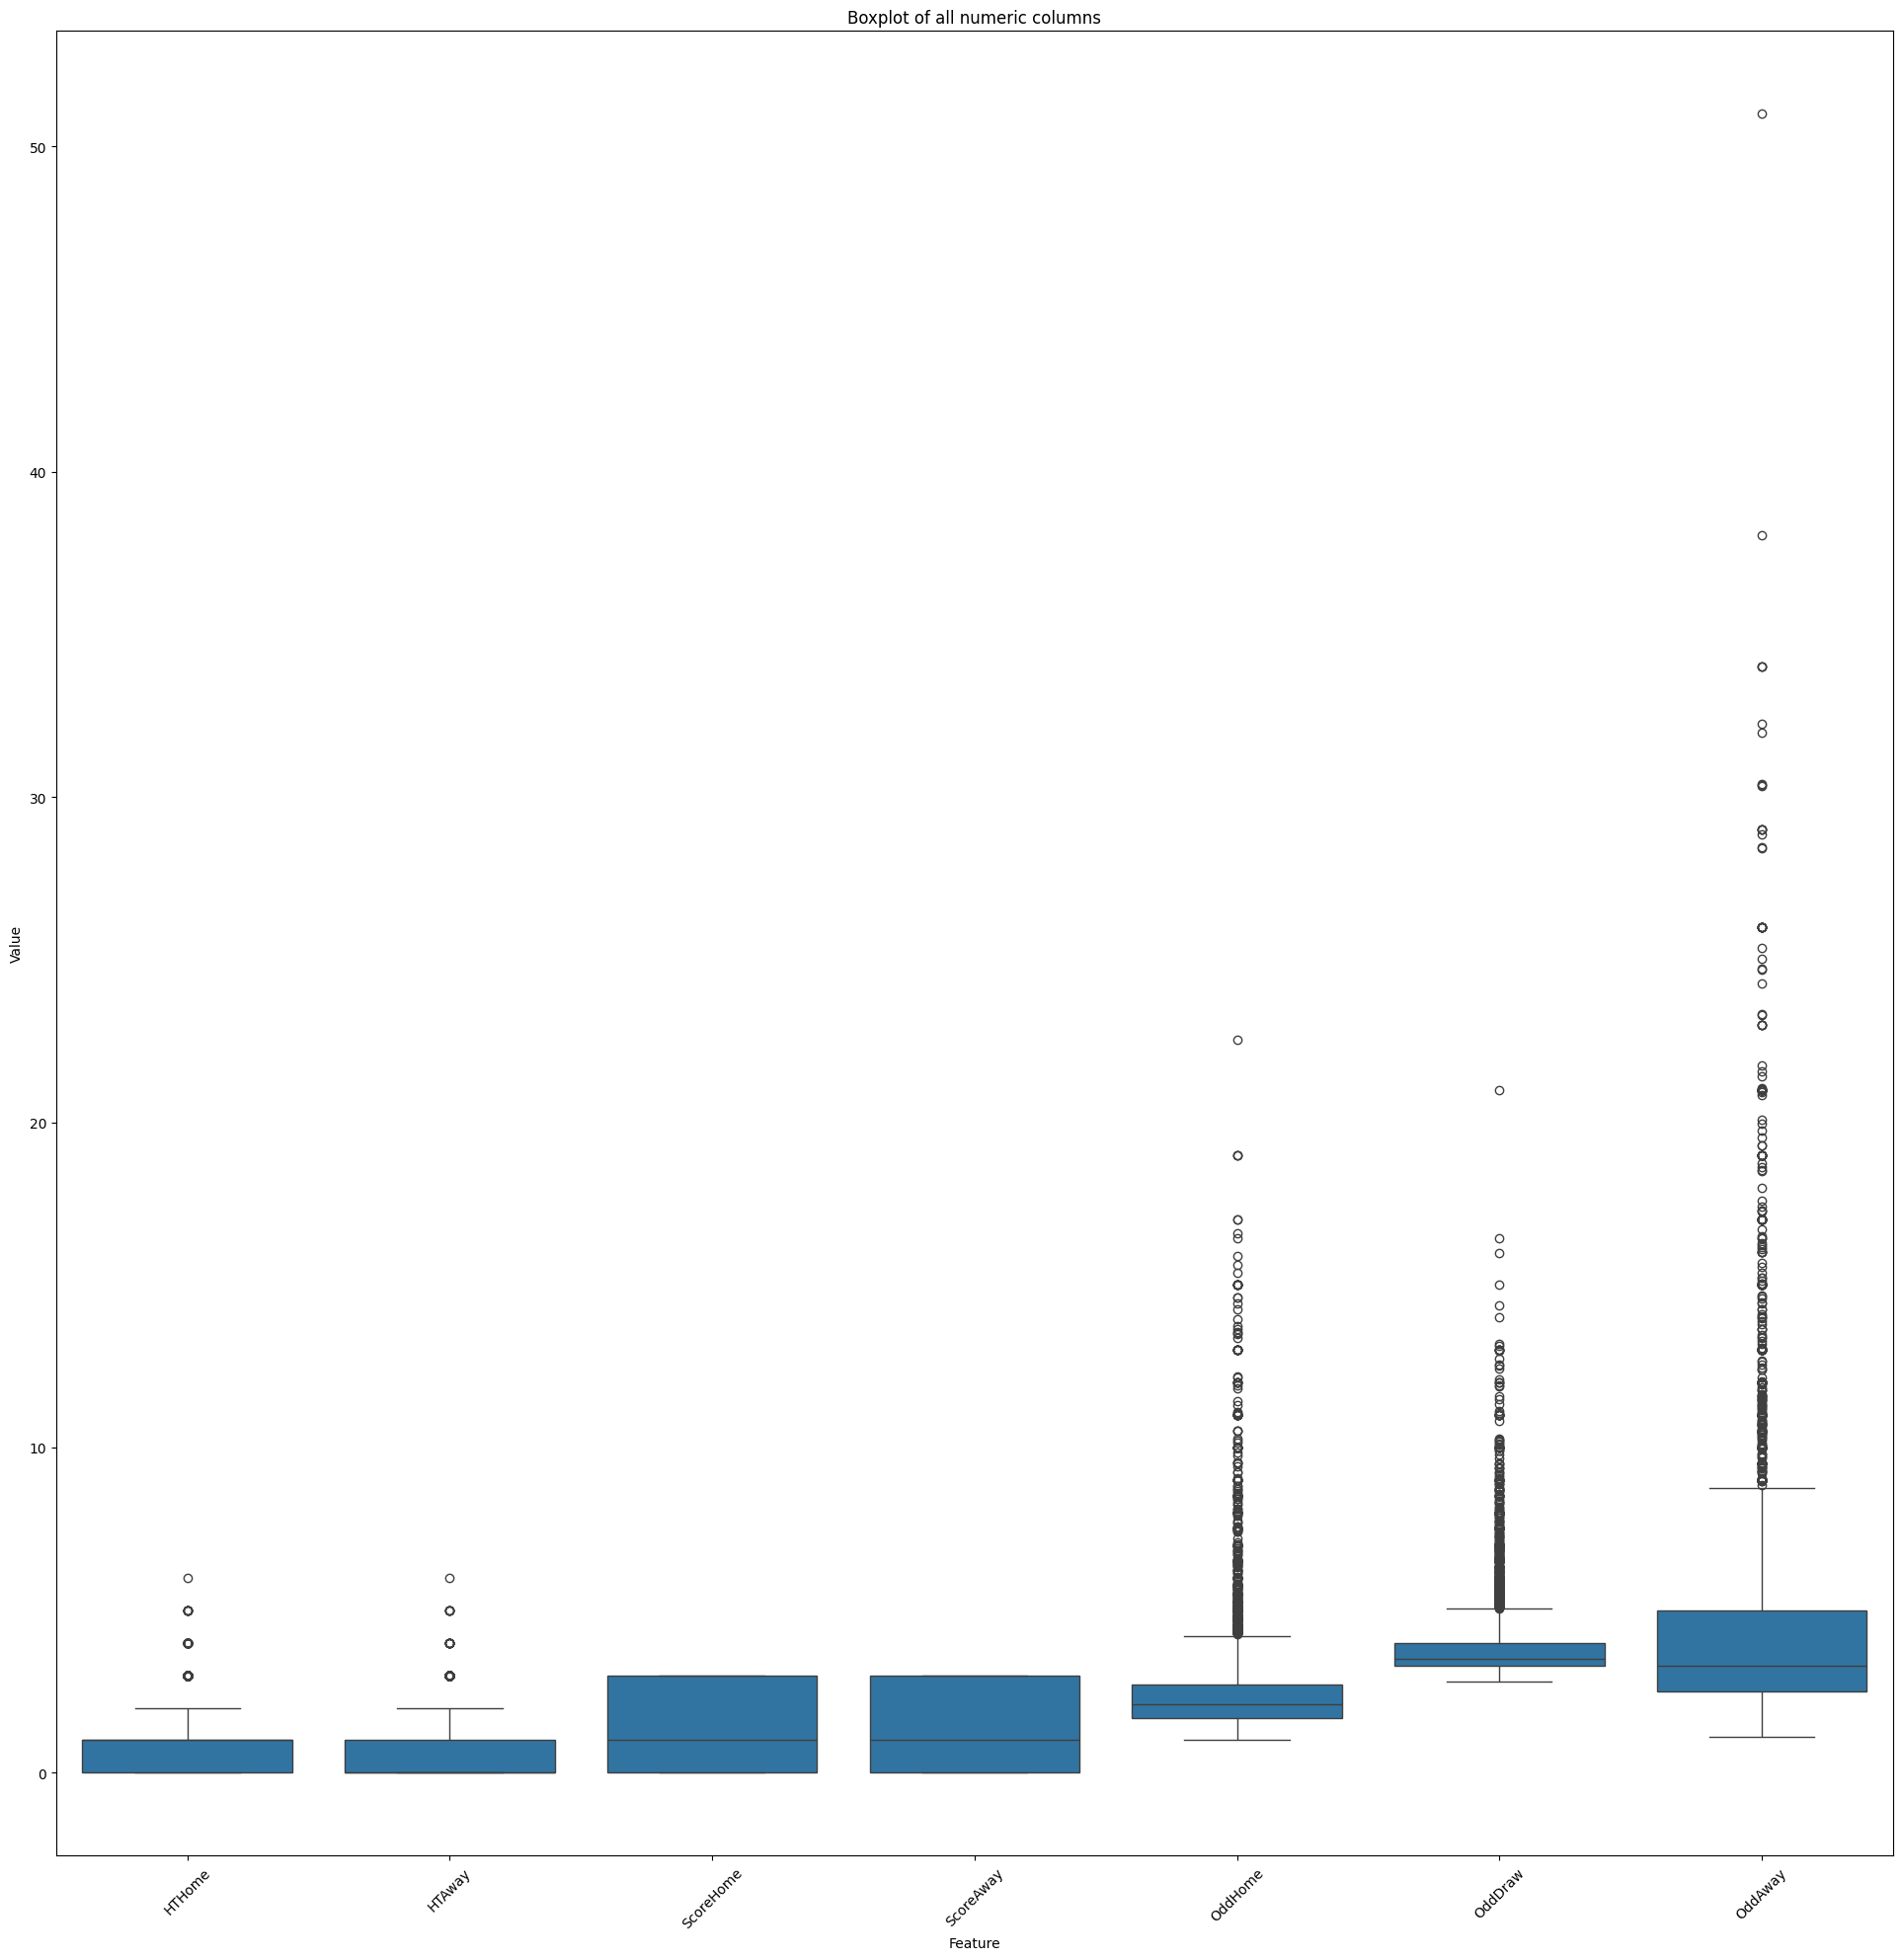

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt


# Melt the DataFrame to long format
num_df = final_Bundesliga_df.select_dtypes(include=['int64', 'float64'])
melted_df = num_df.melt(var_name='Feature', value_name='Value')

plt.figure(figsize=(24,24))
sns.boxplot(x='Feature', y='Value', data=melted_df)
plt.xticks(rotation=45)
plt.title("Boxplot of all numeric columns")
plt.show()


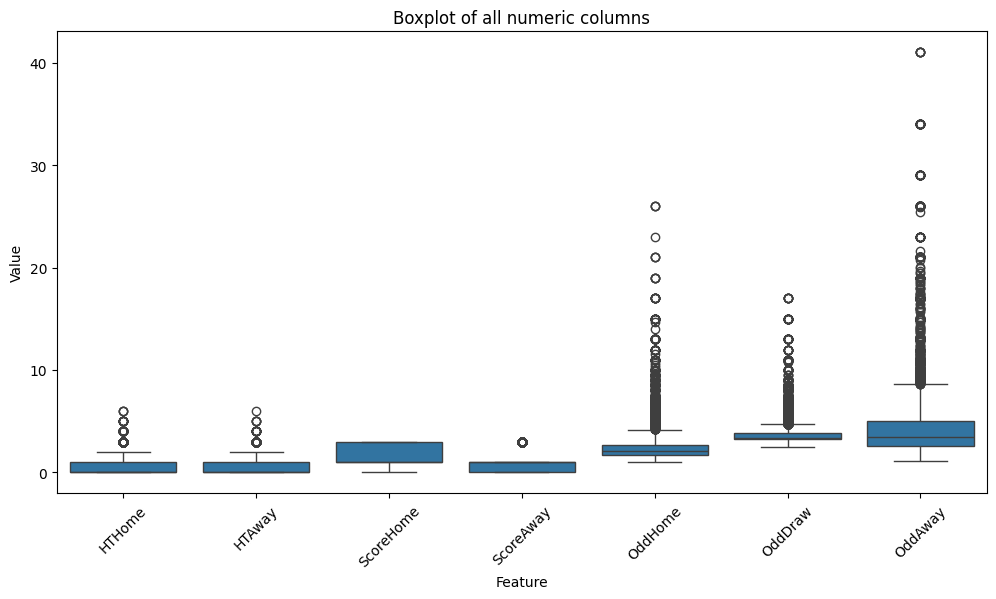

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt


# Melt the DataFrame to long format
num_df = final_La_Liga_df.select_dtypes(include=['int64', 'float64'])
melted_df = num_df.melt(var_name='Feature', value_name='Value')

plt.figure(figsize=(12,6))
sns.boxplot(x='Feature', y='Value', data=melted_df)
plt.xticks(rotation=45)
plt.title("Boxplot of all numeric columns")
plt.show()